##Imports:

In [55]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

##Load Dataset:

In [56]:
# Load dataset directly from local disk (No token or network required)
train_set = load_dataset("parquet", data_files={"train": "data/wildguardtrain.parquet"})
test_set = load_dataset("parquet", data_files={"test": "data/wildguardtest.parquet"})


In [57]:
train_df = train_set['train'].to_pandas()
test_df = test_set['test'].to_pandas()


LABEL_MAP = {
    ("unharmful", False): 0,
    ("unharmful", True): 1,
    ("harmful", False): 2,
    ("harmful", True): 3,
}

TARGET_NAMES = {
    0: "Benign_Vanilla",
    1: "Benign_Adversarial",
    2: "Harmful_Vanilla",
    3: "Harmful_Adversarial",
}

def safe_bool(value):
    if isinstance(value, bool):
        return value
    if isinstance(value, (int, float)):
        return bool(value)
    return str(value).strip().lower() in {"true", "1", "yes", "y", "t"}

def process_target_labels(df):
    before = len(df)

    # Drop rows missing required label columns
    df_clean = df.dropna(subset=['prompt_harm_label', 'adversarial']).copy()

    # Create 4-class target
    df_clean['target'] = [
        LABEL_MAP.get((str(harm).strip().lower(), safe_bool(adv)))
        for harm, adv in zip(
            df_clean['prompt_harm_label'],
            df_clean['adversarial']
        )
    ]

    # Remove rows where mapping failed
    df_clean = df_clean.dropna(subset=['target'])

    # Convert target to int
    df_clean['target'] = df_clean['target'].astype(int)

    # Add readable class name
    df_clean['target_name'] = df_clean['target'].map(TARGET_NAMES)

    print(f"Rows kept: {len(df_clean)}/{before}")

    # Keep only required columns
    return df_clean[['prompt', 'target', 'target_name']]

train_df = process_target_labels(train_df)
test_df = process_target_labels(test_df)

print(train_df['target_name'].value_counts())
print(test_df['target_name'].value_counts())

Rows kept: 86759/86759
Rows kept: 1699/1725
target_name
Harmful_Vanilla        25649
Harmful_Adversarial    20567
Benign_Adversarial     20389
Benign_Vanilla         20154
Name: count, dtype: int64
target_name
Benign_Vanilla         490
Benign_Adversarial     455
Harmful_Vanilla        413
Harmful_Adversarial    341
Name: count, dtype: int64


#EDA:


In [58]:
print("Train Shape: ", train_df.shape)
print("Test Shape: ", test_df.shape)

print("Train Columns: ", train_df.columns.tolist())
print("Test Columns: ", test_df.columns.tolist())

Train Shape:  (86759, 3)
Test Shape:  (1699, 3)
Train Columns:  ['prompt', 'target', 'target_name']
Test Columns:  ['prompt', 'target', 'target_name']


In [59]:
print("Train Data:")
train_df.info()

print("\n" + "=" * 30)

print("Test Data:")
test_df.info()

Train Data:
<class 'pandas.DataFrame'>
RangeIndex: 86759 entries, 0 to 86758
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prompt       86759 non-null  str  
 1   target       86759 non-null  int64
 2   target_name  86759 non-null  str  
dtypes: int64(1), str(2)
memory usage: 44.8 MB

Test Data:
<class 'pandas.DataFrame'>
Index: 1699 entries, 0 to 1724
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prompt       1699 non-null   str  
 1   target       1699 non-null   int64
 2   target_name  1699 non-null   str  
dtypes: int64(1), str(2)
memory usage: 877.1 KB


In [60]:
#Missing Values in train and test data
print(train_df.isnull().sum())

print("\n" + "=" * 30)

print(test_df.isnull().sum())

prompt         0
target         0
target_name    0
dtype: int64

prompt         0
target         0
target_name    0
dtype: int64


In [61]:
#Empty prompts in train and test data
train_empty = train_df[train_df['prompt'].str.strip() == '']
print("Empty prompts in train data: ", train_empty.shape[0])

test_empty = test_df[test_df['prompt'].str.strip() == '']
print("Empty prompts in test data: ", test_empty.shape[0])

Empty prompts in train data:  14
Empty prompts in test data:  0


In [62]:
#Short prompts in train and test data
print("Short prompts in train data: ")
display(train_df[['prompt', 'target_name']].assign(word_count=train_df['prompt'].str.split().str.len()).sort_values("word_count").head(20))

Short prompts in train data: 


,prompt,target_name,word_count
10693,,Benign_Vanilla,0
20839,,Benign_Adversarial,0
37898,,Benign_Vanilla,0
23574,,Benign_Adversarial,0
37891,,Benign_Vanilla,0
38037,,Benign_Vanilla,0
9547,,Benign_Vanilla,0
38081,,Benign_Vanilla,0
38282,,Benign_Vanilla,0
10346,,Benign_Vanilla,0


In [63]:
#Duplicate prompts in train and test data
print("Duplicate prompts in train data: ", 
      train_df["prompt"].duplicated().sum())


print("Duplicate prompts in test data: ", 
      test_df["prompt"].duplicated().sum())

Duplicate prompts in train data:  38907
Duplicate prompts in test data:  0


In [64]:
#Class distribution in train and test data
train_class_counts = train_df['target_name'].value_counts()
print(train_class_counts)

test_class_counts = test_df['target_name'].value_counts()
print(test_class_counts)

target_name
Harmful_Vanilla        25649
Harmful_Adversarial    20567
Benign_Adversarial     20389
Benign_Vanilla         20154
Name: count, dtype: int64
target_name
Benign_Vanilla         490
Benign_Adversarial     455
Harmful_Vanilla        413
Harmful_Adversarial    341
Name: count, dtype: int64


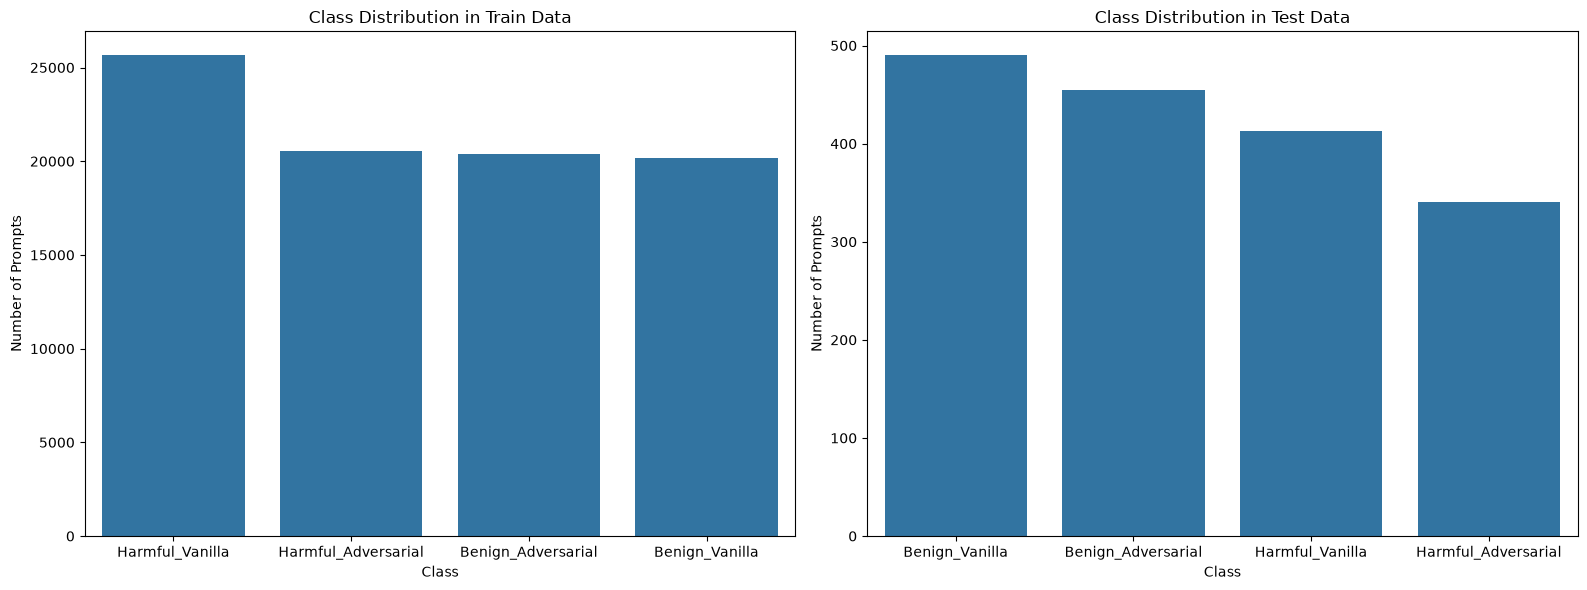

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    data = train_df,
    x = 'target_name',
    order = train_df['target_name'].value_counts().index,
    ax = axes[0]
)
axes[0].set_title("Class Distribution in Train Data")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Prompts")

sns.countplot(
    data = test_df,
    x = 'target_name',
    order = test_df['target_name'].value_counts().index,
    ax = axes[1]
)
axes[1].set_title("Class Distribution in Test Data")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Prompts")

plt.tight_layout() 
plt.show()

In [66]:
train_df = train_df[train_df['prompt'].str.strip() != '']
test_df = test_df[test_df['prompt'].str.strip() != '']


train_df = train_df.drop_duplicates(subset=['prompt'])
test_df = test_df.drop_duplicates(subset=['prompt'])


print("Cleaned Train Shape: ", train_df.shape)
print("Cleaned Test Shape: ", test_df.shape)


Cleaned Train Shape:  (47851, 3)
Cleaned Test Shape:  (1699, 3)


## TF-IDF:

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = vectorizer.fit_transform(train_df['prompt'])
X_test_tfidf = vectorizer.transform(test_df['prompt'])

print("TF-IDF Train Matrix Shape:", X_train_tfidf.shape)
print("TF-IDF Test Matrix Shape:", X_test_tfidf.shape)

TF-IDF Train Matrix Shape: (47851, 5000)
TF-IDF Test Matrix Shape: (1699, 5000)


In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

y_train = train_df['target']
y_test = test_df['target']

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

predictions = model.predict(X_test_tfidf)

print(f"Overall Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")
print(classification_report(y_test, predictions))

Overall Accuracy: 79.05%
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       490
           1       0.79      0.83      0.81       455
           2       0.77      0.79      0.78       413
           3       0.78      0.71      0.74       341

    accuracy                           0.79      1699
   macro avg       0.79      0.78      0.79      1699
weighted avg       0.79      0.79      0.79      1699



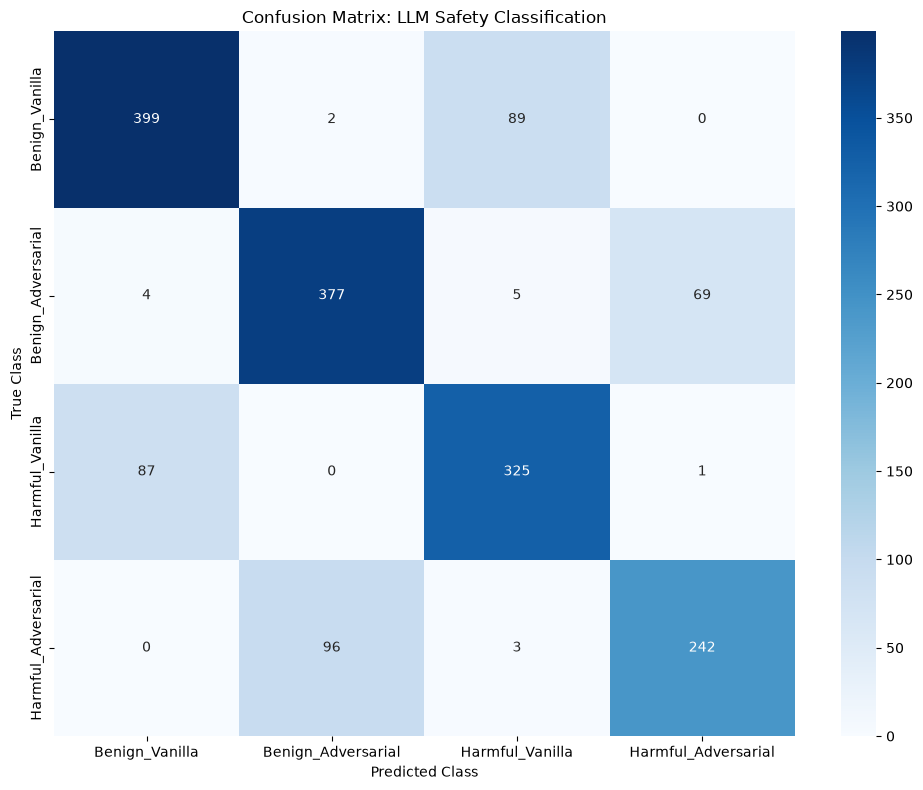

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

class_names = [TARGET_NAMES[i] for i in sorted(TARGET_NAMES.keys())]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.title('Confusion Matrix: LLM Safety Classification')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

rf_predictions = rf_model.predict(X_test_tfidf)

print("\nRandom Forest Results: ")
print(f"Overall Accuracy: {accuracy_score(y_test, rf_predictions) * 100:.2f}%")
print(classification_report(y_test, rf_predictions))

print("\nConfusion Matrix (Raw Numbers):")
print(confusion_matrix(y_test, rf_predictions))


Random Forest Results: 
Overall Accuracy: 73.04%
              precision    recall  f1-score   support

           0       0.79      0.72      0.76       490
           1       0.73      0.78      0.75       455
           2       0.69      0.78      0.73       413
           3       0.69      0.62      0.65       341

    accuracy                           0.73      1699
   macro avg       0.73      0.72      0.72      1699
weighted avg       0.73      0.73      0.73      1699


Confusion Matrix (Raw Numbers):
[[354   1 135   0]
 [  2 354   5  94]
 [ 90   1 321   1]
 [  0 128   1 212]]
